# QETHOS — QSVM with Angle Embedding (v2, fixed)

Quantum-kernel SVM for DeFi fraud detection on **BCCC-DeFiFraudTrans-2025** (CTGAN-balanced),
using an **angle-embedding fidelity kernel**.



## 1. Install dependencies

In [1]:
# Run once per fresh environment.
!pip install pennylane pennylane-lightning --quiet
!pip install scikit-learn xgboost joblib tqdm --quiet
print("deps installed")

deps installed


## 2. Storage setup (Colab Drive / NRP persistent volume)
Environment-aware: mounts Google Drive on Colab, uses a persistent local path on NRP.

In [2]:
import os

def detect_env():
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        if os.path.exists("/content"):
            return "other"
        return "nrp" if os.environ.get("JUPYTERHUB_USER") else "other"

ENV = detect_env()
print("Environment detected:", ENV)

if ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/QETHOS"
else:
    # NRP: point at your persistent volume (PVC). EDIT if yours differs.
    BASE_DIR = os.environ.get("QETHOS_BASE", os.path.expanduser("~/QETHOS"))

os.makedirs(BASE_DIR, exist_ok=True)
print("BASE_DIR:", BASE_DIR)

Environment detected: nrp
BASE_DIR: /home/jovyan/QETHOS


## 3. Imports

In [3]:
# Threading guard: let joblib own CPU parallelism, not OpenMP.
# Each circuit is tiny, so per-circuit OpenMP threads only oversubscribe.
# MUST run before importing pennylane/numpy backends.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, os
import warnings
warnings.filterwarnings("ignore")

import pennylane as qml

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, cohen_kappa_score,
    confusion_matrix, ConfusionMatrixDisplay
)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

SEED = 42
np.random.seed(SEED)
print("Imports OK. PennyLane:", qml.__version__)

Imports OK. PennyLane: 0.45.1


## 4. Configuration

Angle embedding maps each feature to one rotation angle. The amount of the circle the rotations
span is set by `ANGLE_SCALE`: too small and every state looks identical (v1's bug, off-diag≈1),
too large and phases wrap and states look orthogonal (the old ZZ bug, off-diag≈0). The right
value is data-dependent — **don't hard-code it, find it with the Section 12 sweep** and paste
the winner back here.

In [4]:
# --- EDIT THESE ---
AGA_FEATURES = [
    'length_to', 'block_number', 'gas_used', 'chain_id', 'total_gas_cost',
    'effective_gas_price', 'cumulative_gas_used', 'gas_price_ratio', 'length_log'
]
TARGET_COL = "flag"
DATA_PATH  = os.path.join(BASE_DIR, "Data", "ctgan_balanced_400k_dataset.csv") \
             if "BASE_DIR" in globals() \
             else "/content/drive/MyDrive/QETHOS/Data/ctgan_balanced_400k_dataset.csv"
# ------------------

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

# Subsample sizes for the quantum kernel (the O(n^2) cost)
QSVM_SUBSAMPLE_SIZE = 1000     # QSVM training set
QSVM_VAL_SIZE       = 1000     # threshold/C tuning only
QSVM_TEST_SIZE      = 5000     # large for credibility

USE_PCA = False
PCA_COMPONENTS = 8

ANGLE_ROT  = "Y"          # rotation axis: "X", "Y", or "Z"
ANGLE_SCALE = np.pi       # span of the rotation range. PLACEHOLDER - confirm via the sweep.
N_LAYERS   = 1            # data re-uploading repeats; 1-3
DUAL_AXIS  = False        # True -> apply RY AND RZ per feature (extra expressivity, no entangling)

# --- AGA feature weighting (A/B option; only active when USE_PCA=False) ---
AGA_WEIGHTS = np.array([0.76, 0.83, 0.77, 0.93, 0.93, 1.00, 0.79, 0.74, 0.94])
assert len(AGA_WEIGHTS) == len(AGA_FEATURES)
USE_AGA_WEIGHTS = False

# --- Multi-seed stability (headline QSVM). [42] = single run; add seeds for mean±std. ---
SEEDS = [42, 7, 123]   # e.g. [42, 7, 123] to report stability in the paper

# Device
# try:
#     _t = qml.device("lightning.qubit", wires=2); DEVICE = "lightning.qubit"
# except Exception:
#     DEVICE = "default.qubit"
# print("Device:", DEVICE)
_t = qml.device("default.qubit", wires=2); DEVICE = "default.qubit"
# Parallelism
N_JOBS = -1
print(f"Detected {os.cpu_count()} core(s); kernel build n_jobs={N_JOBS}")

CACHE_DIR = os.path.join(BASE_DIR, "angle_cache_v3_default_quibit") if "BASE_DIR" in globals() else "./angle_cache_v3_default_quibit"
os.makedirs(CACHE_DIR, exist_ok=True)

N_QUBITS = PCA_COMPONENTS if USE_PCA else len(AGA_FEATURES)
FEATURE_WEIGHTS = (AGA_WEIGHTS if (USE_AGA_WEIGHTS and not USE_PCA) else np.ones(N_QUBITS))
print(f"Qubits: {N_QUBITS} | rot: {ANGLE_ROT} | angle_scale: {ANGLE_SCALE:.3f} | "
      f"layers: {N_LAYERS} | dual_axis: {DUAL_AXIS} | PCA: {USE_PCA} | AGA weights: {USE_AGA_WEIGHTS}")

Detected 256 core(s); kernel build n_jobs=-1
Qubits: 9 | rot: Y | angle_scale: 3.142 | layers: 1 | dual_axis: False | PCA: False | AGA weights: False


## 5. Load data

In [5]:
df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)
missing = [c for c in AGA_FEATURES + [TARGET_COL] if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

X = df[AGA_FEATURES].astype(float).values
y = df[TARGET_COL].astype(int).values
print("Class balance:", np.bincount(y), "(CTGAN-balanced; no SMOTE needed)")

Loaded: (400000, 10)
Class balance: [200000 200000] (CTGAN-balanced; no SMOTE needed)


## 6. Preprocess: rank-encode into the angle range

Pipeline: **StandardScaler → optional PCA → QuantileTransformer → [0, ANGLE_SCALE]**.

The QuantileTransformer (carried over from the VQC notebook) is the key change from v1's MinMax.
Gas/value features are heavily skewed, so MinMax left almost all mass bunched in the middle of
the range — which is exactly what made every rotation angle nearly identical. Rank-based quantile
encoding spreads samples *uniformly*, so the per-feature std stays high and the kernel can tell
points apart.

We build a single reusable `make_scaler()` so the Section 12 sweep applies the **identical**
preprocessing at each candidate scale.

In [6]:
def make_features(X_raw_tr, X_raw_va, X_raw_te, angle_scale, use_pca=USE_PCA,
                  pca_components=PCA_COMPONENTS, seed=SEED):
    # StandardScaler -> optional PCA -> Quantile(uniform) -> [0, angle_scale]. Fit on train only.
    ss = StandardScaler().fit(X_raw_tr)
    Xtr, Xva, Xte = ss.transform(X_raw_tr), ss.transform(X_raw_va), ss.transform(X_raw_te)

    if use_pca:
        pca = PCA(n_components=pca_components, random_state=seed).fit(Xtr)
        Xtr, Xva, Xte = pca.transform(Xtr), pca.transform(Xva), pca.transform(Xte)

    qt = QuantileTransformer(output_distribution="uniform",
                             n_quantiles=min(1000, len(Xtr)), random_state=seed).fit(Xtr)
    # quantile -> [0,1] -> [0, angle_scale]
    Xtr = qt.transform(Xtr) * angle_scale
    Xva = qt.transform(Xva) * angle_scale
    Xte = qt.transform(Xte) * angle_scale
    return Xtr, Xva, Xte

# Stratified 70/15/15 split on the RAW features (keep raw copies for the sweep)
X_tr_raw, X_tmp_raw, y_tr, y_tmp = train_test_split(
    X, y, test_size=(VAL_RATIO+TEST_RATIO), stratify=y, random_state=SEED)
X_va_raw, X_te_raw, y_va, y_te = train_test_split(
    X_tmp_raw, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)
print(f"Full split -> train {len(X_tr_raw)} | val {len(X_va_raw)} | test {len(X_te_raw)}")

# Apply the pipeline at the chosen ANGLE_SCALE
X_tr, X_va, X_te = make_features(X_tr_raw, X_va_raw, X_te_raw, ANGLE_SCALE)
print(f"Scaled to [0, {ANGLE_SCALE:.3f}]; feature dim = {X_tr.shape[1]} = N_QUBITS={N_QUBITS}")

# --- DEAD-FEATURE CHECK (the early-warning the v1 notebook lacked) ---
stds = X_tr.std(axis=0)
print("\nPer-feature std after encoding (want all comfortably > 0):")
print(np.round(stds, 3))
if (stds < 1e-3).any():
    print("  WARNING: at least one feature is near-constant -> it adds no kernel signal.")
else:
    print("  OK: every feature carries spread.")

Full split -> train 280000 | val 60000 | test 60000
Scaled to [0, 3.142]; feature dim = 9 = N_QUBITS=9

Per-feature std after encoding (want all comfortably > 0):
[0.266 0.905 0.869 1.369 0.905 0.903 0.905 0.013 0.879]
  OK: every feature carries spread.


## 7. Subsample for the quantum kernel

In [7]:
def stratified_subsample(Xa, ya, n, seed=SEED):
    if n >= len(Xa): return Xa, ya
    Xs, _, ys, _ = train_test_split(Xa, ya, train_size=n, stratify=ya, random_state=seed)
    return Xs, ys

X_train_q, y_train_q = stratified_subsample(X_tr, y_tr, QSVM_SUBSAMPLE_SIZE)
X_val_q,   y_val_q   = stratified_subsample(X_va, y_va, QSVM_VAL_SIZE)
X_test_q,  y_test_q  = stratified_subsample(X_te, y_te, QSVM_TEST_SIZE)
print("QSVM sets:", X_train_q.shape, X_val_q.shape, X_test_q.shape)
print("train balance:", np.bincount(y_train_q))

QSVM sets: (1000, 9) (1000, 9) (5000, 9)
train balance: [500 500]


## 8. Angle-embedding fidelity kernel

For each layer, apply `Rot_axis(weights[i] * x[i])` on qubit *i* (optionally a second RZ rotation
if `DUAL_AXIS`). The kernel is the fidelity: embed `x1` forward, then the **adjoint** embedding of
`x2`, and read the probability of the all-zeros outcome, which equals |⟨φ(x2)|φ(x1)⟩|².

No entangling gates, no product terms — the deliberate contrast with the ZZ map.

In [8]:
dev = qml.device(DEVICE, wires=N_QUBITS)

_ROT = {"X": qml.RX, "Y": qml.RY, "Z": qml.RZ}[ANGLE_ROT]

def angle_embed(x, wires, weights=None, layers=N_LAYERS, dual=DUAL_AXIS):
    if weights is None:
        weights = FEATURE_WEIGHTS
    xs = weights * x
    for _ in range(layers):
        for i, w in enumerate(wires):
            _ROT(xs[i], wires=w)
            if dual:
                qml.RZ(xs[i], wires=w)   # same feature on a second axis (from VQC notebook)

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    angle_embed(x1, wires=range(N_QUBITS))
    qml.adjoint(angle_embed)(x2, wires=range(N_QUBITS))
    return qml.probs(wires=range(N_QUBITS))

def quantum_kernel(x1, x2):
    return kernel_circuit(x1, x2)[0]

print(qml.draw(kernel_circuit)(X_train_q[0], X_train_q[1]))

0: ──RY(3.14)──RY(3.14)†─┤ ╭Probs
1: ──RY(1.11)──RY(0.90)†─┤ ├Probs
2: ──RY(2.90)──RY(2.96)†─┤ ├Probs
3: ──RY(3.14)──RY(0.00)†─┤ ├Probs
4: ──RY(0.68)──RY(2.87)†─┤ ├Probs
5: ──RY(0.26)──RY(1.84)†─┤ ├Probs
6: ──RY(2.29)──RY(1.30)†─┤ ├Probs
7: ──RY(3.14)──RY(3.14)†─┤ ├Probs
8: ──RY(0.00)──RY(3.07)†─┤ ╰Probs


### Parallel kernel build (HPC-ready, pickle-safe)

Each loky worker builds its **own** device + QNode (the C++ state vector can't be pickled across
processes). Only NumPy arrays cross the boundary. The large test matrix saves in chunks so a
disconnect resumes.

In [9]:
from joblib import Parallel, delayed

def _kernel_row(xi, Xb, n_qubits, rot, weights, layers, dual, device):
    import pennylane as _qml
    import numpy as _np
    _dev = _qml.device(device, wires=n_qubits)
    _R = {"X": _qml.RX, "Y": _qml.RY, "Z": _qml.RZ}[rot]
    def _emb(x, wires):
        xs = weights * x
        for _ in range(layers):
            for i, w in enumerate(wires):
                _R(xs[i], wires=w)
                if dual:
                    _qml.RZ(xs[i], wires=w)
    @_qml.qnode(_dev)
    def _circ(a, b):
        _emb(a, wires=range(n_qubits))
        _qml.adjoint(_emb)(b, wires=range(n_qubits))
        return _qml.probs(wires=range(n_qubits))
    return _np.array([_circ(xi, xb)[0] for xb in Xb])

def _args(Xa, i, Xb):
    return (Xa[i], Xb, N_QUBITS, ANGLE_ROT, FEATURE_WEIGHTS, N_LAYERS, DUAL_AXIS, DEVICE)

def build_kernel_parallel(Xa, Xb, label, n_jobs=N_JOBS):
    na, nb_ = len(Xa), len(Xb)
    print(f"[{label}] ({na} x {nb_}) = {na*nb_:,} evals | n_jobs={n_jobs}")
    t0 = time.time()
    rows = Parallel(n_jobs=n_jobs, backend="loky", verbose=5)(
        delayed(_kernel_row)(*_args(Xa, i, Xb)) for i in range(na))
    K = np.vstack(rows)
    print(f"  [{label}] {time.time()-t0:.1f}s -> {K.shape}")
    return K

def build_kernel_chunked(Xa, Xb, label, chunk_rows=250, n_jobs=N_JOBS):
    na, nb_ = len(Xa), len(Xb)
    cdir = os.path.join(CACHE_DIR, f"{label}_chunks"); os.makedirs(cdir, exist_ok=True)
    nchunks = (na + chunk_rows - 1)//chunk_rows
    print(f"[{label}] ({na} x {nb_}) in {nchunks} chunks | n_jobs={n_jobs}")
    t0 = time.time()
    for c in range(nchunks):
        cp = os.path.join(cdir, f"chunk_{c:04d}.npy")
        if os.path.exists(cp): continue
        r0, r1 = c*chunk_rows, min((c+1)*chunk_rows, na)
        rows = Parallel(n_jobs=n_jobs, backend="loky")(
            delayed(_kernel_row)(*_args(Xa, i, Xb)) for i in range(r0, r1))
        np.save(cp, np.vstack(rows))
        el = time.time()-t0; eta = el/r1*(na-r1)
        print(f"  chunk {c+1}/{nchunks} | {el:.0f}s | ETA {eta:.0f}s")
    blocks = [np.load(os.path.join(cdir, f"chunk_{c:04d}.npy")) for c in range(nchunks)]
    return np.vstack(blocks)

def cached(path, builder):
    full = os.path.join(CACHE_DIR, path)
    if os.path.exists(full):
        print("Loading cached", path); return np.load(full)
    K = builder(); np.save(full, K); print("Saved", path); return K

# tag encodes every knob that changes the kernel -> new config never reuses an old cache
tag = (f"{ANGLE_ROT}_L{N_LAYERS}_q{N_QUBITS}_s{ANGLE_SCALE:.2f}"
       f"_{'pca' if USE_PCA else 'raw'}_{'dual' if DUAL_AXIS else 'single'}"
       f"_{'agaW' if USE_AGA_WEIGHTS else 'unif'}")
print("cache tag:", tag)

K_train = cached(f"K_train_{tag}.npy", lambda: build_kernel_parallel(X_train_q, X_train_q, "train"))
K_val   = cached(f"K_val_{tag}.npy",   lambda: build_kernel_parallel(X_val_q,   X_train_q, "val"))

K_test_path = os.path.join(CACHE_DIR, f"K_test_{tag}.npy")
if os.path.exists(K_test_path):
    print("Loading cached test kernel"); K_test = np.load(K_test_path)
else:
    K_test = build_kernel_chunked(X_test_q, X_train_q, f"test_{tag}", chunk_rows=250)
    np.save(K_test_path, K_test); print("Saved test kernel")

print("Shapes:", K_train.shape, K_val.shape, K_test.shape)

cache tag: Y_L1_q9_s3.14_raw_single_unif
Loading cached K_train_Y_L1_q9_s3.14_raw_single_unif.npy
Loading cached K_val_Y_L1_q9_s3.14_raw_single_unif.npy
Loading cached test kernel
Shapes: (1000, 1000) (1000, 1000) (5000, 1000)


## 9. Kernel diagnostics (concentration + alignment)

**Read this before trusting any downstream metric.** If off-diagonal std is tiny or KTA≈0, the
kernel is concentrated and the SVM is fitting noise — go back to Section 12 and pick a better
`ANGLE_SCALE`. A healthy kernel has off-diagonal mean roughly in 0.2–0.8 and KTA clearly above 0.

In [10]:
def kta(K, y):
    ys = np.where(np.asarray(y)==1, 1.0, -1.0)
    Y = np.outer(ys, ys)
    return float((K*Y).sum()/(np.linalg.norm(K)*np.linalg.norm(Y)+1e-12))

off = K_train[~np.eye(len(K_train), dtype=bool)]
align = kta(K_train, y_train_q)
print("Train kernel diagnostics")
print(f"  diagonal     : mean={np.diag(K_train).mean():.4f} (should be ~1.0)")
print(f"  off-diagonal : mean={off.mean():.4f} std={off.std():.4f} "
      f"range=[{off.min():.4f}, {off.max():.4f}]")
print(f"  KTA (train)  : {align:.4f} (higher is better; ~0 means no label signal)")

if off.mean() > 0.98:
    print("  WARNING: off-diagonal mean near 1 -> kernel concentrating to identical "
          "(INCREASE ANGLE_SCALE / N_LAYERS / try DUAL_AXIS).")
elif off.mean() < 0.02:
    print("  WARNING: off-diagonal mean near 0 -> states near-orthogonal "
          "(DECREASE ANGLE_SCALE / N_LAYERS).")
elif off.std() < 0.02:
    print("  WARNING: low spread -> weak separation.")
elif align < 0.02:
    print("  WARNING: KTA near 0 -> kernel does not track labels; re-sweep.")
else:
    print("  OK: usable structure with label signal.")

Train kernel diagnostics
  diagonal     : mean=1.0000 (should be ~1.0)
  off-diagonal : mean=0.1295 std=0.2210 range=[0.0000, 1.0000]
  KTA (train)  : 0.1424 (higher is better; ~0 means no label signal)
  OK: usable structure with label signal.


## 10. Train QSVM (tuned C + threshold) and classical baselines

In [11]:
# C tuning on val F1
C_VALUES = [0.01, 0.1, 0.5, 1, 10, 100]
best_C, best_f1 = None, -1
for C in C_VALUES:
    clf = SVC(kernel="precomputed", C=C, class_weight="balanced", random_state=SEED)
    clf.fit(K_train, y_train_q)
    f1 = f1_score(y_val_q, clf.predict(K_val), zero_division=0)
    print(f"  C={C:<6} Val F1={f1:.4f}")
    if f1 > best_f1: best_f1, best_C = f1, C
print("Best C:", best_C, f"(Val F1={best_f1:.4f})")
if best_C == max(C_VALUES):
    print("  NOTE: best C is the largest tried and lower C was flat -> kernel may still be weak")
    print("        (SVM leaning on regularisation, not structure). Re-check Section 9 KTA.")

t0 = time.time()
qsvm = SVC(kernel="precomputed", C=best_C, class_weight="balanced",
           probability=True, random_state=SEED).fit(K_train, y_train_q)
qsvm_time = time.time()-t0

# Threshold tuning on val
vp = qsvm.predict_proba(K_val)[:,1]
ths = np.linspace(0.1, 0.9, 81)
BEST_THRESH = float(ths[int(np.argmax([f1_score(y_val_q,(vp>=t).astype(int),zero_division=0) for t in ths]))])
print(f"Best threshold (val F1): {BEST_THRESH:.3f}")

  C=0.01   Val F1=0.8213
  C=0.1    Val F1=0.8694
  C=0.5    Val F1=0.8809
  C=1      Val F1=0.8809
  C=10     Val F1=0.8851
  C=100    Val F1=0.8589
Best C: 10 (Val F1=0.8851)
Best threshold (val F1): 0.400


In [12]:
def evaluate(name, yt, yp, yprob=None, tt=None):
    row = {"Model":name,
           "Accuracy":accuracy_score(yt,yp), "Precision":precision_score(yt,yp,zero_division=0),
           "Recall":recall_score(yt,yp,zero_division=0), "F1":f1_score(yt,yp,zero_division=0),
           "Kappa":cohen_kappa_score(yt,yp),
           "AUC":roc_auc_score(yt,yprob) if yprob is not None else np.nan,
           "Train Time (s)":tt}
    print(f"\n=== {name} (test N={len(yt)}) ===")
    for k,v in row.items():
        if k=="Model": continue
        print(f"  {k:<14}: {v:.4f}" if isinstance(v,float) else f"  {k:<14}: {v}")
    return row

qsvm_prob = qsvm.predict_proba(K_test)[:,1]
qsvm_pred = (qsvm_prob >= BEST_THRESH).astype(int)

results = [evaluate(f"QSVM (Angle-{ANGLE_ROT}, thr={BEST_THRESH:.2f})",
                    y_test_q, qsvm_pred, qsvm_prob, qsvm_time)]

# Classical baselines on the SAME scaled features (no SMOTE; CTGAN-balanced) -- fair comparison
t0=time.time(); rbf=SVC(kernel="rbf", C=10, probability=True, random_state=SEED).fit(X_train_q,y_train_q); rbf_t=time.time()-t0
results.append(evaluate("Classical SVM (RBF)", y_test_q, rbf.predict(X_test_q), rbf.predict_proba(X_test_q)[:,1], rbf_t))

t0=time.time(); rf=RandomForestClassifier(n_estimators=200,random_state=SEED,n_jobs=-1).fit(X_train_q,y_train_q); rf_t=time.time()-t0
results.append(evaluate("Random Forest", y_test_q, rf.predict(X_test_q), rf.predict_proba(X_test_q)[:,1], rf_t))

if XGB_AVAILABLE:
    t0=time.time(); xgb=XGBClassifier(n_estimators=200,random_state=SEED,n_jobs=-1,
                                      use_label_encoder=False, eval_metric="logloss").fit(X_train_q,y_train_q)
    xgb_t=time.time()-t0
    results.append(evaluate("XGBoost", y_test_q, xgb.predict(X_test_q), xgb.predict_proba(X_test_q)[:,1], xgb_t))

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(CACHE_DIR, f"results_{tag}.csv"), index=False)
results_df


=== QSVM (Angle-Y, thr=0.40) (test N=5000) ===
  Accuracy      : 0.8914
  Precision     : 0.8733
  Recall        : 0.9156
  F1            : 0.8940
  Kappa         : 0.7828
  AUC           : 0.9533
  Train Time (s): 0.0263

=== Classical SVM (RBF) (test N=5000) ===
  Accuracy      : 0.8906
  Precision     : 0.8831
  Recall        : 0.9004
  F1            : 0.8917
  Kappa         : 0.7812
  AUC           : 0.9577
  Train Time (s): 0.0599

=== Random Forest (test N=5000) ===
  Accuracy      : 0.9214
  Precision     : 0.9186
  Recall        : 0.9248
  F1            : 0.9217
  Kappa         : 0.8428
  AUC           : 0.9775
  Train Time (s): 0.2739

=== XGBoost (test N=5000) ===
  Accuracy      : 0.9144
  Precision     : 0.9144
  Recall        : 0.9144
  F1            : 0.9144
  Kappa         : 0.8288
  AUC           : 0.9717
  Train Time (s): 0.0726


,Model,Accuracy,Precision,Recall,F1,Kappa,AUC,Train Time (s)
0,"QSVM (Angle-Y, thr=0.40)",0.8914,0.873331,0.9156,0.893966,0.7828,0.953292,0.026263
1,Classical SVM (RBF),0.8906,0.883091,0.9004,0.891662,0.7812,0.957701,0.059855
2,Random Forest,0.9214,0.918554,0.9248,0.921666,0.8428,0.977461,0.273893
3,XGBoost,0.9144,0.914400,0.9144,0.914400,0.8288,0.971722,0.072563


## 11. Confusion matrices

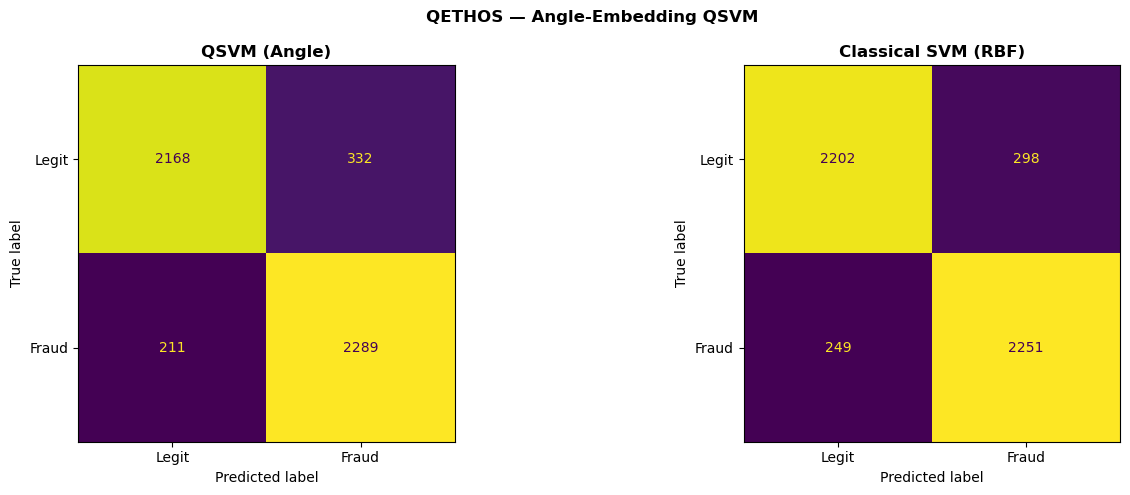

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax,(name,yp) in zip(axes, [("QSVM (Angle)", qsvm_pred), ("Classical SVM (RBF)", rbf.predict(X_test_q))]):
    ConfusionMatrixDisplay(confusion_matrix(y_test_q, yp),
        display_labels=["Legit","Fraud"]).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontweight="bold")
plt.suptitle("QETHOS — Angle-Embedding QSVM", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, f"confusion_{tag}.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. ANGLE_SCALE × rot × layers sweep  ← run this FIRST

This is the cell that finds a working configuration **before** you pay for a full kernel build.
It screens on a small 300-point kernel (seconds each) and scores every candidate by KTA. Crucially
it varies `ANGLE_SCALE` — the knob v1 never swept — and re-runs the *full* preprocessing pipeline
at each scale on the raw split, so there's no double-scaling and no stale `X_tr`.

**How to read it:** take the highest-KTA row whose `off_mean` is roughly 0.2–0.8. Copy its
`scale` / `rot` / `layers` into Section 4, restart-and-run, and check Section 9 shows real
structure. If everything is still pinned near off_mean≈1, set `SWEEP_DUAL=True` and/or widen the
scale list; if still stuck, the features themselves lack separable signal at this subsample size.

In [14]:
RUN_SWEEP = True
SWEEP_DUAL = False        # also try dual-axis (RY+RZ) variants
SWEEP_SCALES = [np.pi/2, np.pi, 1.5*np.pi, 2*np.pi, 2.5*np.pi, 3*np.pi]
SWEEP_ROTS   = ["Y", "X"]
SWEEP_LAYERS = [1, 2, 3]

if not RUN_SWEEP:
    print("RUN_SWEEP=False -> skipping.")
else:
    print("Sweep starting...")
    n_scr = 300

    def small_kernel(Xa, rot, layers, dual):
        _dev = qml.device(DEVICE, wires=Xa.shape[1])
        _R = {"X": qml.RX, "Y": qml.RY, "Z": qml.RZ}[rot]
        def emb(x, wires):
            for _ in range(layers):
                for i, w in enumerate(wires):
                    _R(x[i], wires=w)
                    if dual:
                        qml.RZ(x[i], wires=w)
        @qml.qnode(_dev)
        def circ(a, b):
            emb(a, wires=range(Xa.shape[1]))
            qml.adjoint(emb)(b, wires=range(Xa.shape[1]))
            return qml.probs(wires=range(Xa.shape[1]))
        m = len(Xa); K = np.zeros((m, m))
        for i in range(m):
            for j in range(i, m):
                v = circ(Xa[i], Xa[j])[0]; K[i, j] = K[j, i] = v
        return K

    # Pre-subsample 300 raw TRAIN rows ONCE (same rows across every scale -> fair comparison)
    Xtr_raw_s, ytr_s = stratified_subsample(X_tr_raw, y_tr, n_scr)
    dual_opts = [False, True] if SWEEP_DUAL else [False]

    rows = []
    for scale in SWEEP_SCALES:
        # full pipeline at THIS scale; val/test args are dummies we ignore
        Xs, _, _ = make_features(Xtr_raw_s, Xtr_raw_s, Xtr_raw_s, scale)
        for rot in SWEEP_ROTS:
            for layers in SWEEP_LAYERS:
                for dual in dual_opts:
                    K = small_kernel(Xs, rot, layers, dual)
                    o = K[~np.eye(len(K), dtype=bool)]
                    a = kta(K, ytr_s)
                    rows.append({"scale": round(scale,3), "rot": rot, "layers": layers,
                                 "dual": dual, "KTA": round(a,4),
                                 "off_mean": round(o.mean(),4), "off_std": round(o.std(),4)})
                    print(f"  scale={scale:.3f} rot={rot} L={layers} dual={dual} "
                          f"| KTA={a:.4f} | off_mean={o.mean():.4f} off_std={o.std():.4f}")

    sweep_df = pd.DataFrame(rows).sort_values("KTA", ascending=False).reset_index(drop=True)
    # flag the rows in the healthy off_mean band
    sweep_df["usable_band"] = sweep_df["off_mean"].between(0.2, 0.8)
    print("\n=== Top by KTA (usable_band=True is what you want) ===")
    print(sweep_df.head(15).to_string(index=False))
    sweep_df.to_csv(os.path.join(CACHE_DIR, "scale_sweep.csv"), index=False)
    best = sweep_df[sweep_df.usable_band].head(1)
    if len(best):
        b = best.iloc[0]
        print(f"\nSuggested config -> ANGLE_SCALE={b['scale']}, ANGLE_ROT='{b['rot']}', "
              f"N_LAYERS={int(b['layers'])}, DUAL_AXIS={bool(b['dual'])}  (KTA={b['KTA']})")
    else:
        print("\nNo row landed in off_mean 0.2-0.8. Widen SWEEP_SCALES or set SWEEP_DUAL=True, "
              "or try USE_PCA=False. The signal may be weak at 300 points -- try n_scr=500.")

Sweep starting...
  scale=1.571 rot=Y L=1 dual=False | KTA=0.0879 | off_mean=0.4592 off_std=0.2412
  scale=1.571 rot=Y L=2 dual=False | KTA=0.1684 | off_mean=0.1206 off_std=0.2159
  scale=1.571 rot=Y L=3 dual=False | KTA=0.2331 | off_mean=0.0655 off_std=0.1474
  scale=1.571 rot=X L=1 dual=False | KTA=0.0879 | off_mean=0.4592 off_std=0.2412
  scale=1.571 rot=X L=2 dual=False | KTA=0.1684 | off_mean=0.1206 off_std=0.2159
  scale=1.571 rot=X L=3 dual=False | KTA=0.2331 | off_mean=0.0655 off_std=0.1474
  scale=3.142 rot=Y L=1 dual=False | KTA=0.1684 | off_mean=0.1206 off_std=0.2159
  scale=3.142 rot=Y L=2 dual=False | KTA=0.2184 | off_mean=0.0526 off_std=0.1320
  scale=3.142 rot=Y L=3 dual=False | KTA=0.1249 | off_mean=0.0253 off_std=0.0926
  scale=3.142 rot=X L=2 dual=False | KTA=0.2184 | off_mean=0.0526 off_std=0.1320
  scale=3.142 rot=X L=3 dual=False | KTA=0.1249 | off_mean=0.0253 off_std=0.0926
  scale=4.712 rot=Y L=1 dual=False | KTA=0.2331 | off_mean=0.0655 off_std=0.1474
  scale=4.

## 13. (Optional) Multi-seed stability for the headline QSVM

Reviewers will ask whether your number is a lucky split. This re-runs the **chosen** config across
the seeds in `SEEDS` (rebuilding the train kernel each time on a fresh subsample) and reports
mean ± std for the QSVM. It reuses everything already configured above, so only run it once you've
locked `ANGLE_SCALE` from the sweep. Costs one train-kernel build per seed.

In [25]:
RUN_MULTISEED = True   # set True after locking the config from Section 12

if RUN_MULTISEED and len(SEEDS) >= 1:
    seed_rows = []
    for sd in SEEDS:
        Xtrq, ytrq = stratified_subsample(X_tr, y_tr, QSVM_SUBSAMPLE_SIZE, seed=sd)
        Xvaq, yvaq = stratified_subsample(X_va, y_va, QSVM_VAL_SIZE, seed=sd)
        Xteq, yteq = stratified_subsample(X_te, y_te, QSVM_TEST_SIZE, seed=sd)

        Ktr = build_kernel_parallel(Xtrq, Xtrq, f"train_seed{sd}")
        Kva = build_kernel_parallel(Xvaq, Xtrq, f"val_seed{sd}")
        Kte = build_kernel_chunked(Xteq, Xtrq, f"test_seed{sd}", chunk_rows=250)

        bC, bF = None, -1
        for C in C_VALUES:
            c = SVC(kernel="precomputed", C=C, class_weight="balanced", random_state=sd).fit(Ktr, ytrq)
            f = f1_score(yvaq, c.predict(Kva), zero_division=0)
            if f > bF: bF, bC = f, C
        m = SVC(kernel="precomputed", C=bC, class_weight="balanced",
                probability=True, random_state=sd).fit(Ktr, ytrq)
        vpp = m.predict_proba(Kva)[:,1]
        th = float(ths[int(np.argmax([f1_score(yvaq,(vpp>=t).astype(int),zero_division=0) for t in ths]))])
        pr = m.predict_proba(Kte)[:,1]; pd_ = (pr>=th).astype(int)
        seed_rows.append({"seed":sd,
                  "Precision":precision_score(yteq, pd_, zero_division=0),
                  "Recall":recall_score(yteq, pd_, zero_division=0),
                  "F1":f1_score(yteq, pd_, zero_division=0),
                  "AUC":roc_auc_score(yteq, pr),
                  "Acc":accuracy_score(yteq, pd_),
                  "Kappa":cohen_kappa_score(yteq, pd_)})
        print(f"seed {sd}: F1={seed_rows[-1]['F1']:.4f} AUC={seed_rows[-1]['AUC']:.4f}")

    sdf = pd.DataFrame(seed_rows)
    print("\nPer-seed:"); print(sdf.to_string(index=False))
    print("\nMean ± std:")
    for col in ["Precision","Recall","F1","AUC","Acc","Kappa"]:
        print(f"  {col:<6}: {sdf[col].mean():.4f} ± {sdf[col].std():.4f}")
    sdf.to_csv(os.path.join(CACHE_DIR, f"multiseed_{tag}.csv"), index=False)
else:
    print("RUN_MULTISEED=False -> skipping. Lock the config from Section 12 first, then set True.")

[train_seed42] (1000 x 1000) = 1,000,000 evals | n_jobs=-1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   29.8s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   54.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  3.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


  [train_seed42] 223.6s -> (1000, 1000)
[val_seed42] (1000 x 1000) = 1,000,000 evals | n_jobs=-1


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   22.9s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   50.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  3.5min finished


  [val_seed42] 211.0s -> (1000, 1000)
[test_seed42] (5000 x 1000) in 20 chunks | n_jobs=-1
seed 42: F1=0.8940 AUC=0.9533
[train_seed7] (1000 x 1000) = 1,000,000 evals | n_jobs=-1


...

  [val_seed7] 215.8s -> (1000, 1000)
[test_seed7] (5000 x 1000) in 20 chunks | n_jobs=-1
seed 7: F1=0.8807 AUC=0.9442
[train_seed123] (1000 x 1000) = 1,000,000 evals | n_jobs=-1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   24.4s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   52.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  3.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


  [train_seed123] 215.6s -> (1000, 1000)
[val_seed123] (1000 x 1000) = 1,000,000 evals | n_jobs=-1


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:   50.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 584 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 818 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  3.6min finished


  [val_seed123] 215.0s -> (1000, 1000)
[test_seed123] (5000 x 1000) in 20 chunks | n_jobs=-1
seed 123: F1=0.8875 AUC=0.9537

Per-seed:
 seed  Precision  Recall       F1      AUC    Acc  Kappa
   42   0.873331  0.9156 0.893966 0.953292 0.8914 0.7828
    7   0.881716  0.8796 0.880657 0.944229 0.8808 0.7616
  123   0.862864  0.9136 0.887507 0.953696 0.8842 0.7684

Mean ± std:
  Precision: 0.8726 ± 0.0094
  Recall: 0.9029 ± 0.0202
  F1    : 0.8874 ± 0.0067
  AUC   : 0.9504 ± 0.0054
  Acc   : 0.8855 ± 0.0054
  Kappa : 0.7709 ± 0.0108


In [22]:
# ===== Multi-seed stability for the classical RBF-SVM baseline =====
# Same seeds, same subsamples, same threshold tuning as the QSVM above,
# so the two kernel methods are directly comparable.
RUN_RBF_MULTISEED = True

if RUN_RBF_MULTISEED and len(SEEDS) >= 1:
    rbf_rows = []
    for sd in SEEDS:
        # identical subsamples to the QSVM loop
        Xtrq, ytrq = stratified_subsample(X_tr, y_tr, QSVM_SUBSAMPLE_SIZE, seed=sd)
        Xvaq, yvaq = stratified_subsample(X_va, y_va, QSVM_VAL_SIZE, seed=sd)
        Xteq, yteq = stratified_subsample(X_te, y_te, QSVM_TEST_SIZE, seed=sd)

        # tune C on validation F1, same grid as the QSVM
        bC, bF = None, -1
        for C in C_VALUES:
            c = SVC(kernel="rbf", C=C, class_weight="balanced",
                    random_state=sd).fit(Xtrq, ytrq)
            f = f1_score(yvaq, c.predict(Xvaq), zero_division=0)
            if f > bF: bF, bC = f, C

        m = SVC(kernel="rbf", C=bC, class_weight="balanced",
                probability=True, random_state=sd).fit(Xtrq, ytrq)

        # threshold tuned on validation, applied once to test
        vpp = m.predict_proba(Xvaq)[:, 1]
        th = float(ths[int(np.argmax([f1_score(yvaq, (vpp >= t).astype(int),
                                               zero_division=0) for t in ths]))])
        pr = m.predict_proba(Xteq)[:, 1]
        pd_ = (pr >= th).astype(int)

        rbf_rows.append({"seed": sd,
                         "Precision": precision_score(yteq, pd_, zero_division=0),
                         "Recall":    recall_score(yteq, pd_, zero_division=0),
                         "F1":        f1_score(yteq, pd_, zero_division=0),
                         "Acc":       accuracy_score(yteq, pd_),
                         "AUC":       roc_auc_score(yteq, pr)})
        print(f"seed {sd}: F1={rbf_rows[-1]['F1']:.4f} AUC={rbf_rows[-1]['AUC']:.4f} (C={bC})")

    rdf = pd.DataFrame(rbf_rows)
    print("\nPer-seed (RBF-SVM):"); print(rdf.to_string(index=False))
    print("\nMean ± std:")
    for col in ["Precision", "Recall", "F1", "Acc", "AUC"]:
        print(f"  {col:<10}: {rdf[col].mean():.4f} ± {rdf[col].std():.4f}")
    rdf.to_csv(os.path.join(CACHE_DIR, f"multiseed_rbf_{tag}.csv"), index=False)
else:
    print("RUN_RBF_MULTISEED=False -> skipping.")

seed 42: F1=0.8918 AUC=0.9577 (C=10)
seed 7: F1=0.8927 AUC=0.9565 (C=10)
seed 123: F1=0.8876 AUC=0.9620 (C=10)

Per-seed (RBF-SVM):
 seed  Precision  Recall       F1    Acc      AUC
   42   0.853953  0.9332 0.891820 0.8868 0.957701
    7   0.861018  0.9268 0.892699 0.8886 0.956532
  123   0.856452  0.9212 0.887647 0.8834 0.962005

Mean ± std:
  Precision : 0.8571 ± 0.0036
  Recall    : 0.9271 ± 0.0060
  F1        : 0.8907 ± 0.0027
  Acc       : 0.8863 ± 0.0026
  AUC       : 0.9587 ± 0.0029


## 14. Publication circuit figures

Two figures for the paper: the **feature map** φ(x) alone (the encoding — cleaner, goes in
methodology) and the full **kernel circuit** (embed x1, then adjoint-embed x2 — goes in an
appendix if you want to show how the fidelity kernel is computed).

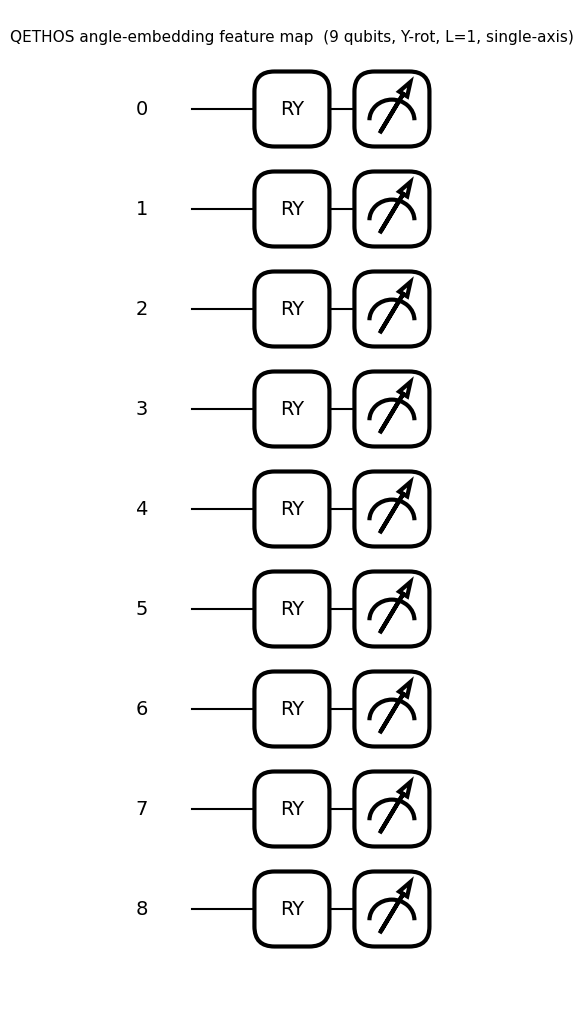

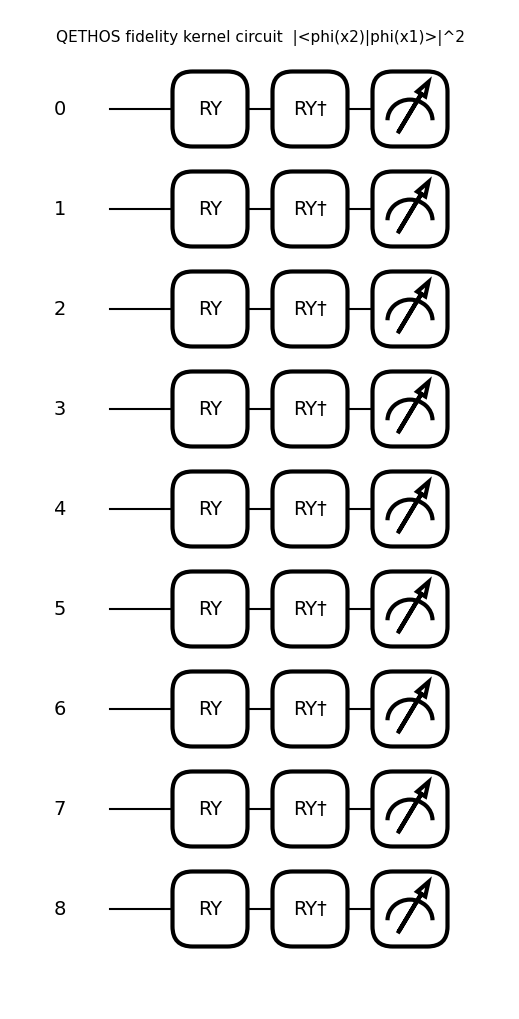

Saved featuremap and circuit PNGs to /home/jovyan/QETHOS/angle_cache_v3_default_quibit


In [16]:
# Feature map only (the encoding) -- methodology figure
@qml.qnode(dev)
def feature_map_only(x):
    angle_embed(x, wires=range(N_QUBITS))
    return qml.probs(wires=range(N_QUBITS))

fig, ax = qml.draw_mpl(feature_map_only)(X_train_q[0])
fig.suptitle(f"QETHOS angle-embedding feature map  "
             f"({N_QUBITS} qubits, {ANGLE_ROT}-rot, L={N_LAYERS}, "
             f"{'dual-axis' if DUAL_AXIS else 'single-axis'})", fontsize=11)
fig.savefig(os.path.join(CACHE_DIR, f"featuremap_{tag}.png"), dpi=200, bbox_inches="tight")
plt.show()

# Full kernel circuit (embed + adjoint) -- appendix figure
fig2, ax2 = qml.draw_mpl(kernel_circuit)(X_train_q[0], X_train_q[1])
fig2.suptitle(f"QETHOS fidelity kernel circuit  |<phi(x2)|phi(x1)>|^2", fontsize=11)
fig2.savefig(os.path.join(CACHE_DIR, f"circuit_{tag}.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved featuremap and circuit PNGs to", CACHE_DIR)

## 15. Adversarial robustness (ART) — fair QSVM vs SVM comparison

**Why this is set up the way it is.** FGSM/PGD are gradient-based and need the model's own
gradients. The QSVM is `SVC(kernel="precomputed")` — it never sees raw features at attack time,
only the precomputed Gram matrix, so it has no differentiable input→decision path ART can use.
Attacking the classical SVM white-box while attacking the QSVM only by transfer would be
**unfair** (the QSVM would face weaker attacks). So we attack **both models identically** with
two gradient-free-on-the-target methods:

1. **Transfer attack (FGSM + PGD).** One differentiable surrogate (logistic regression) is trained
   on the shared scaled features. Perturbations are crafted against the surrogate, then the *same*
   adversarial samples are fed through both the QSVM pipeline and the classical SVM. Identical
   inputs, identical attack — apples to apples.
2. **Black-box query attack (HopSkipJump).** Decision-based, gradient-free; queries each model's
   own predictions directly. Equally valid for QSVM and SVM.

**Honest caveats to put in the paper:** (a) these are transfer + black-box attacks, not white-box
on the QSVM; (b) HopSkipJump on the QSVM is *slow* (every query re-embeds and rebuilds kernel
rows vs. the train set), so it runs on a small sample. Both are stated limitations, not flaws.

In [17]:
# Install ART once per environment
!pip install adversarial-robustness-toolbox --quiet
import art
print("ART", art.__version__)

ART 1.20.1


In [18]:
from sklearn.linear_model import LogisticRegression
from art.estimators.classification import SklearnClassifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, HopSkipJump

# ---- helper: push ANY feature matrix through the full QSVM pipeline ----
# (perturbed samples are already in scaled [0, ANGLE_SCALE] space, same as X_*_q)
def qsvm_predict_features(Xfeat):
    Kc = build_kernel_parallel(np.asarray(Xfeat), X_train_q, "adv", n_jobs=N_JOBS)
    return qsvm.predict(Kc)

def qsvm_predict_features_small(Xfeat):
    # serial version for tiny sets (HopSkipJump) -- avoids loky overhead per query batch
    rows = [_kernel_row(*_args(np.asarray(Xfeat), i, X_train_q)) for i in range(len(Xfeat))]
    return qsvm.predict(np.vstack(rows))

# ---- attack set: a fresh slice of TEST we haven't used for tuning ----
N_ADV = 200                         # transfer attacks (FGSM/PGD) are cheap -> use more
N_ADV_HSJ = 50                      # HopSkipJump is expensive -> keep small
X_adv0 = X_test_q[:N_ADV].astype(np.float32)
y_adv0 = y_test_q[:N_ADV]
EPSILONS = [0.05, 0.1, 0.2, 0.3, 0.5]   # perturbation budget (in angle units)

# clean baselines on the attack set
qsvm_clean = qsvm.predict(build_kernel_parallel(X_adv0, X_train_q, "clean_q"))
csvm_clean = rbf.predict(X_adv0)
print(f"CLEAN  | QSVM acc={accuracy_score(y_adv0,qsvm_clean):.4f} "
      f"F1={f1_score(y_adv0,qsvm_clean,zero_division=0):.4f} "
      f"|| cSVM acc={accuracy_score(y_adv0,csvm_clean):.4f} "
      f"F1={f1_score(y_adv0,csvm_clean,zero_division=0):.4f}")

[clean_q] (200 x 1000) = 200,000 evals | n_jobs=-1


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   16.3s
[Parallel(n_jobs=-1)]: Done 178 out of 200 | elapsed:   24.9s remaining:    3.1s


  [clean_q] 27.1s -> (200, 1000)
CLEAN  | QSVM acc=0.9500 F1=0.9524 || cSVM acc=0.9400 F1=0.9429


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   27.1s finished


In [19]:
# ===== Transfer attacks: FGSM + PGD via a shared surrogate =====
surrogate = LogisticRegression(max_iter=1000).fit(X_train_q, y_train_q)
art_surr  = SklearnClassifier(model=surrogate, clip_values=(0.0, float(ANGLE_SCALE)))

rows = []
for eps in EPSILONS:
    for name, atk in [
        ("FGSM", FastGradientMethod(estimator=art_surr, eps=eps)),
        ("PGD",  ProjectedGradientDescent(estimator=art_surr, eps=eps,
                                          eps_step=eps/4, max_iter=10, verbose=False)),
    ]:
        Xadv = atk.generate(x=X_adv0)
        q = qsvm_predict_features(Xadv)
        c = rbf.predict(Xadv)
        r = {"attack": name, "eps": eps,
             "QSVM_acc": accuracy_score(y_adv0, q), "QSVM_F1": f1_score(y_adv0, q, zero_division=0),
             "cSVM_acc": accuracy_score(y_adv0, c), "cSVM_F1": f1_score(y_adv0, c, zero_division=0)}
        rows.append(r)
        print(f"{name:4s} eps={eps:<4} | QSVM F1={r['QSVM_F1']:.3f} acc={r['QSVM_acc']:.3f} "
              f"|| cSVM F1={r['cSVM_F1']:.3f} acc={r['cSVM_acc']:.3f}")

transfer_df = pd.DataFrame(rows)
transfer_df.to_csv(os.path.join(CACHE_DIR, f"art_transfer_{tag}.csv"), index=False)
transfer_df

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


[adv] (200 x 1000) = 200,000 evals | n_jobs=-1


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   16.1s
[Parallel(n_jobs=-1)]: Done 178 out of 200 | elapsed:   24.8s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   27.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


  [adv] 27.0s -> (200, 1000)
FGSM eps=0.05 | QSVM F1=0.947 acc=0.945 || cSVM F1=0.948 acc=0.945
[adv] (200 x 1000) = 200,000 evals | n_jobs=-1


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   16.2s
[Parallel(n_jobs=-1)]: Done 178 out of 200 | elapsed:   24.9s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   27.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

  [adv] 26.9s -> (200, 1000)
FGSM eps=0.5  | QSVM F1=0.726 acc=0.675 || cSVM F1=0.748 acc=0.710
[adv] (200 x 1000) = 200,000 evals | n_jobs=-1


[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    4.2s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:   16.1s
[Parallel(n_jobs=-1)]: Done 178 out of 200 | elapsed:   24.7s remaining:    3.1s


  [adv] 27.0s -> (200, 1000)
PGD  eps=0.5  | QSVM F1=0.726 acc=0.675 || cSVM F1=0.748 acc=0.710


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   27.0s finished


,attack,eps,QSVM_acc,QSVM_F1,cSVM_acc,cSVM_F1
0,FGSM,0.05,0.945,0.947368,0.945,0.948357
1,PGD,0.05,0.945,0.947368,0.945,0.948357
2,FGSM,0.10,0.920,0.924528,0.950,0.953271
3,PGD,0.10,0.920,0.924528,0.950,0.953271
4,FGSM,0.20,0.900,0.907407,0.890,0.900000
5,PGD,0.20,0.900,0.907407,0.890,0.900000
6,FGSM,0.30,0.855,0.866359,0.830,0.848214
7,PGD,0.30,0.855,0.866359,0.830,0.848214
8,FGSM,0.50,0.675,0.725738,0.710,0.747826
9,PGD,0.50,0.675,0.725738,0.710,0.747826


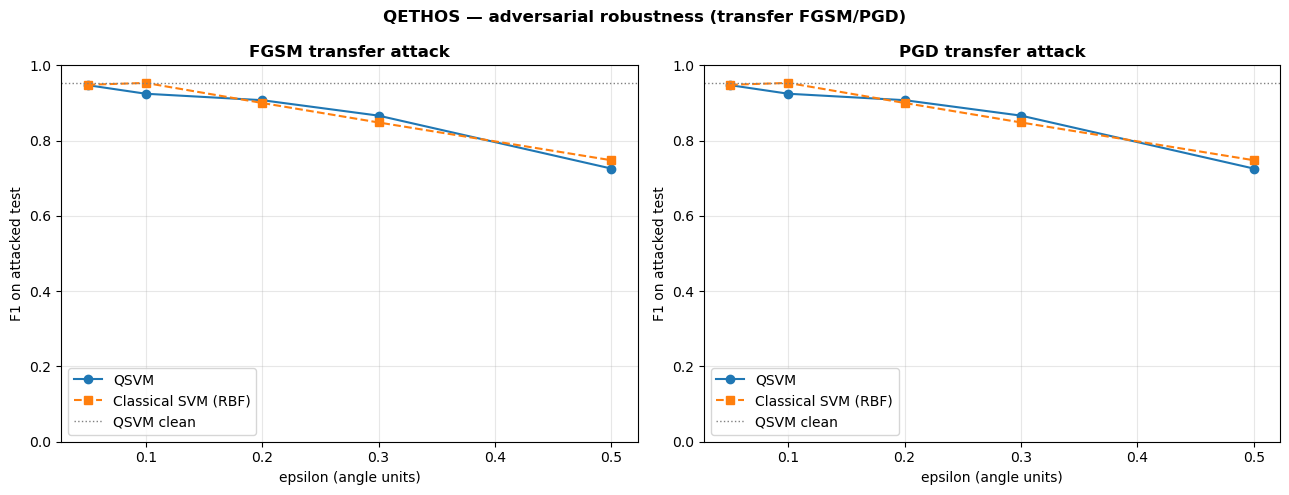

In [20]:
# ===== Robustness degradation curves (transfer attacks) =====
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, atk in zip(axes, ["FGSM", "PGD"]):
    sub = transfer_df[transfer_df.attack == atk]
    ax.plot(sub.eps, sub.QSVM_F1, "o-", label="QSVM")
    ax.plot(sub.eps, sub.cSVM_F1, "s--", label="Classical SVM (RBF)")
    ax.axhline(f1_score(y_adv0, qsvm_clean, zero_division=0), color="gray", ls=":", lw=1, label="QSVM clean")
    ax.set_title(f"{atk} transfer attack", fontweight="bold")
    ax.set_xlabel("epsilon (angle units)"); ax.set_ylabel("F1 on attacked test")
    ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("QETHOS — adversarial robustness (transfer FGSM/PGD)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CACHE_DIR, f"art_curves_{tag}.png"), dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# ===== Black-box HopSkipJump — self-contained, no external predict helper =====
# Computes the QSVM fidelity kernel inline (analytic, no simulator).
# Valid for: single-axis rotation, no entangling gates. Matches kernel_circuit.
RUN_HSJ = True

if RUN_HSJ:
    from art.attacks.evasion import HopSkipJump
    from art.estimators.classification import BlackBoxClassifier

    N_HSJ = 100
    Xh = X_test_q[:N_HSJ].astype(np.float32)
    yh = y_test_q[:N_HSJ]

    # --- inline analytic fidelity kernel (single-axis, no entanglement) ---
    # For RY(a) and RY(b) on the same qubit, the single-qubit fidelity is
    # cos^2((a-b)/2). The full-state fidelity is the product over qubits.
    # angle_i = FEATURE_WEIGHTS[i] * x[i], repeated N_LAYERS times (layers just
    # scale the angle linearly here since there are no entangling gates).
    def _angles(X):
        return (FEATURE_WEIGHTS * X) * N_LAYERS   # (n, 9) rotation angles

    def analytic_kernel(Xa, Xb):
        A = _angles(np.asarray(Xa, dtype=np.float64))   # (na, 9)
        B = _angles(np.asarray(Xb, dtype=np.float64))   # (nb, 9)
        # pairwise angle differences per qubit -> cos^2(diff/2) -> product over qubits
        diff = A[:, None, :] - B[None, :, :]            # (na, nb, 9)
        per_qubit = np.cos(diff / 2.0) ** 2             # (na, nb, 9)
        return np.prod(per_qubit, axis=2)               # (na, nb)

    # sanity check against the simulator kernel on a few pairs (optional but recommended)
    try:
        K_sim = np.array([[kernel_circuit(Xh[i], X_train_q[j])[0]
                           for j in range(5)] for i in range(5)])
        K_an  = analytic_kernel(Xh[:5], X_train_q[:5])
        print("analytic vs simulator max abs diff:",
              float(np.max(np.abs(K_sim - K_an))))
    except Exception as e:
        print("sanity check skipped:", e)

    # QSVM prediction from raw features, using the analytic kernel
    def qsvm_predict(Xfeat):
        K = analytic_kernel(np.asarray(Xfeat), X_train_q)   # (n, n_train)
        return qsvm.predict(K)

    def median_l2(X_clean, X_adv, flipped):
        d = np.linalg.norm((X_adv - X_clean).reshape(len(X_clean), -1), axis=1)
        return float(np.median(d[flipped])) if flipped.any() else float("nan")

    # ---- classical RBF-SVM (direct) ----
    csvm_clean = rbf.predict(Xh)
    art_csvm = SklearnClassifier(model=rbf, clip_values=(0.0, float(ANGLE_SCALE)))
    hsj_c = HopSkipJump(classifier=art_csvm, max_iter=20, max_eval=1000,
                        init_eval=20, verbose=False)
    Xc = hsj_c.generate(x=Xh)
    c_adv = rbf.predict(Xc)
    c_flip = (c_adv != csvm_clean)
    print(f"cSVM | clean acc={accuracy_score(yh, csvm_clean):.3f} | "
          f"flipped {c_flip.mean():.2%} | median L2={median_l2(Xh, Xc, c_flip):.4f}")

    # ---- QSVM (black-box via analytic predict) ----
    q_clean = qsvm_predict(Xh)
    def qsvm_bb_predict(x):
        preds = qsvm_predict(np.asarray(x, dtype=np.float32))
        oh = np.zeros((len(preds), 2)); oh[np.arange(len(preds)), preds.astype(int)] = 1.0
        return oh
    art_qsvm = BlackBoxClassifier(predict_fn=qsvm_bb_predict,
                                  input_shape=(N_QUBITS,), nb_classes=2,
                                  clip_values=(0.0, float(ANGLE_SCALE)))
    hsj_q = HopSkipJump(classifier=art_qsvm, max_iter=20, max_eval=1000,
                        init_eval=20, verbose=False)
    Xq = hsj_q.generate(x=Xh)
    q_adv = qsvm_predict(Xq)
    q_flip = (q_adv != q_clean)
    print(f"QSVM | clean acc={accuracy_score(yh, q_clean):.3f} | "
          f"flipped {q_flip.mean():.2%} | median L2={median_l2(Xh, Xq, q_flip):.4f}")

    hsj_df = pd.DataFrame([
        {"model": "QSVM", "clean_acc": accuracy_score(yh, q_clean),
         "flip_rate": q_flip.mean(), "median_L2": median_l2(Xh, Xq, q_flip)},
        {"model": "cSVM", "clean_acc": accuracy_score(yh, csvm_clean),
         "flip_rate": c_flip.mean(), "median_L2": median_l2(Xh, Xc, c_flip)},
    ])
    hsj_df.to_csv(os.path.join(CACHE_DIR, f"art_hsj_{tag}.csv"), index=False)
    print(hsj_df.to_string(index=False))
else:
    print("RUN_HSJ=False -> skipping.")

analytic vs simulator max abs diff: 3.3306690738754696e-16
cSVM | clean acc=0.940 | flipped 99.00% | median L2=1.0698
QSVM | clean acc=0.960 | flipped 100.00% | median L2=0.8611
model  clean_acc  flip_rate  median_L2
 QSVM       0.96       1.00   0.861089
 cSVM       0.94       0.99   1.069812
